# 03 — Phase-2 walk-forward (S3 HP, 6-config grid)

**Inputs:** `results/phase2_walkforward_base.parquet`, `results/phase2_walkforward_regime.parquet`.

**Outputs for the deck:** ticker × fold Sharpe heatmap, parameter selection stacked bar (which λ wins where), per-ticker aggregate table.

Grid: λ ∈ {1600, 14400, 129600} × window ∈ {252, 504}; 3y train / 1y test / 1y step over the constituent universe. Fold count per variant scales with the 2015-start window — see the `fold_id` column in the parquet for the exact tally.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.plots.figures import (
    apply_style, walkforward_heatmap, param_selection_stack,
)
from config import RESULTS_DIR

apply_style()

wf_base = pd.read_parquet(RESULTS_DIR / "phase2_walkforward_base.parquet")
wf_regime = pd.read_parquet(RESULTS_DIR / "phase2_walkforward_regime.parquet")

## 1. Headline numbers

Mean / median test Sharpe, % folds Sharpe>0, mean test MDD, total trades — per variant. The 2015→present window leaves only a handful of disjoint test folds per ticker, so treat these as a sanity check that out-of-sample Sharpe stays positive on average, not as the headline metric.

In [2]:
def _summary(df: pd.DataFrame, name: str) -> dict:
    return {
        "variant": name,
        "n_folds": len(df),
        "n_tickers": df["ticker"].nunique(),
        "mean_test_sharpe": df["test_sharpe"].mean(),
        "median_test_sharpe": df["test_sharpe"].median(),
        "pct_sharpe_gt_0": (df["test_sharpe"] > 0).mean(),
        "mean_test_mdd": df["test_max_drawdown"].mean(),
        "total_trades": int(df["test_n_trades"].sum()),
    }

summary = pd.DataFrame([_summary(wf_base, "base"), _summary(wf_regime, "regime")])
print(summary.round({"mean_test_sharpe": 3, "median_test_sharpe": 3,
                     "pct_sharpe_gt_0": 3, "mean_test_mdd": 4}).to_string(index=False))

variant  n_folds  n_tickers  mean_test_sharpe  median_test_sharpe  pct_sharpe_gt_0  mean_test_mdd  total_trades
   base      391         67             0.681               0.711            0.737        -0.3468         10570
 regime      391         67             0.551               0.556            0.701        -0.3030          7306


## 2. Ticker × fold Sharpe heatmap

`walkforward_heatmap(wf_base)` for the base variant; same for regime. RdBu colormap centered at 0 makes negative folds pop visually.

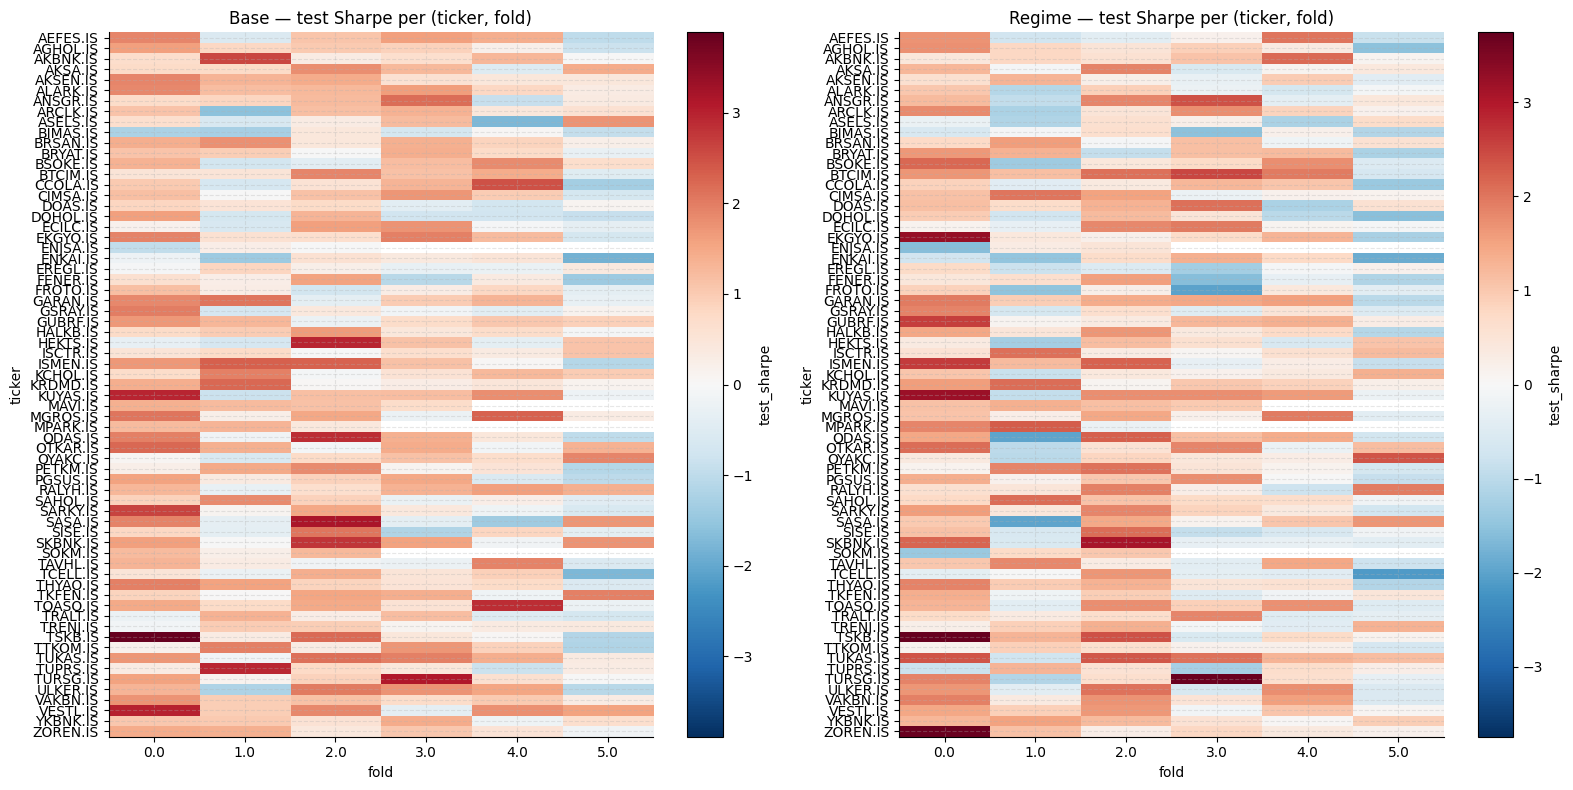

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
walkforward_heatmap(wf_base, ax=axes[0])
axes[0].set_title("Base — test Sharpe per (ticker, fold)")
walkforward_heatmap(wf_regime, ax=axes[1])
axes[1].set_title("Regime — test Sharpe per (ticker, fold)")
plt.tight_layout()
plt.show()

## 3. Parameter selection over folds

`param_selection_stack(wf_base)` — counts of how often each `(λ, window)` pair wins, stacked per fold. The shorter window typically dominates and the λ choice is more evenly spread; the grid intentionally over-covers so we can see which corner is unused and prune the next sweep.

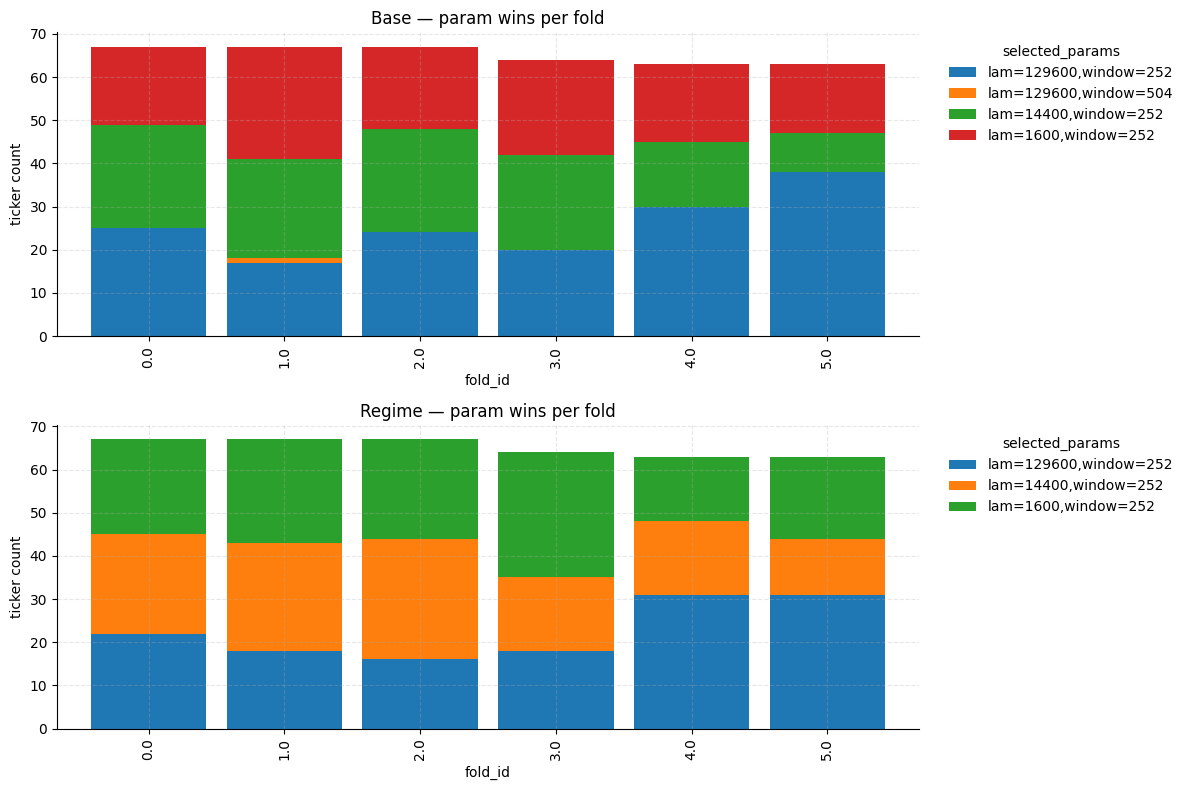


Overall param selection counts (base):
selected_params
lam=129600,window=252    154
lam=1600,window=252      119
lam=14400,window=252     117
lam=129600,window=504      1

Overall param selection counts (regime):
selected_params
lam=129600,window=252    136
lam=1600,window=252      132
lam=14400,window=252     123


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
param_selection_stack(wf_base, ax=axes[0])
axes[0].set_title("Base — param wins per fold")
param_selection_stack(wf_regime, ax=axes[1])
axes[1].set_title("Regime — param wins per fold")
plt.tight_layout()
plt.show()

print("\nOverall param selection counts (base):")
print(wf_base["selected_params"].value_counts().to_string())
print("\nOverall param selection counts (regime):")
print(wf_regime["selected_params"].value_counts().to_string())

## 4. Per-ticker aggregate table

GroupBy ticker: mean fold Sharpe, % folds positive, mean test trades. Sorted to surface the best and worst constituents under walk-forward — the ranking is not stable across windows (the 2015→present slice loses the 2003–2014 bull-trend regime that lifted some of the original CLAUDE.md leaders), so read the table rather than the prose for the current leaderboard.

In [5]:
per_ticker = (
    wf_base.groupby("ticker")
    .agg(folds=("fold_id", "count"),
         mean_sharpe=("test_sharpe", "mean"),
         pct_positive=("test_sharpe", lambda s: (s > 0).mean()),
         mean_test_trades=("test_n_trades", "mean"),
         mean_mdd=("test_max_drawdown", "mean"))
    .round({"mean_sharpe": 3, "pct_positive": 3, "mean_test_trades": 1, "mean_mdd": 4})
    .sort_values("mean_sharpe", ascending=False)
)
print("Top 7 by mean fold Sharpe (base):")
print(per_ticker.head(7).to_string())
print("\nBottom 7:")
print(per_ticker.tail(7).to_string())

Top 7 by mean fold Sharpe (base):
          folds  mean_sharpe  pct_positive  mean_test_trades  mean_mdd
ticker                                                                
VESTL.IS      6        1.471         0.833              26.8   -0.2620
SKBNK.IS      6        1.252         0.667              27.5   -0.3400
TUKAS.IS      6        1.243         0.833              28.7   -0.3209
ALARK.IS      6        1.179         1.000              18.5   -0.2750
TOASO.IS      6        1.145         0.833              22.2   -0.2602
MAVI.IS       4        1.119         1.000              17.8   -0.2719
ISMEN.IS      6        1.064         0.833              23.7   -0.3790

Bottom 7:
          folds  mean_sharpe  pct_positive  mean_test_trades  mean_mdd
ticker                                                                
DOAS.IS       6        0.179         0.667              27.5   -0.4332
EREGL.IS      6        0.140         0.500              24.5   -0.3526
FENER.IS      6        0.051    